In [4]:
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode="human")

obs, info = env.reset()

for step in range(200):
    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    print("step:", step)
    print("obs:", obs)
    print("reward:", reward)
    print("done:", done)
    print("------")

    if done:
        print("EPISODE BİTTİ\n")
        obs, info = env.reset()

env.close()

step: 0
obs: [-0.01796203 -0.177526   -0.01246217  0.2545764 ]
reward: 1.0
done: False
------
step: 1
obs: [-0.02151255 -0.37246782 -0.00737065  0.54330266]
reward: 1.0
done: False
------
step: 2
obs: [-0.02896191 -0.17724307  0.00349541  0.24830653]
reward: 1.0
done: False
------
step: 3
obs: [-0.03250677  0.01782879  0.00846154 -0.04327182]
reward: 1.0
done: False
------
step: 4
obs: [-0.0321502  -0.17741346  0.0075961   0.25206873]
reward: 1.0
done: False
------
step: 5
obs: [-0.03569847  0.0175992   0.01263748 -0.03820858]
reward: 1.0
done: False
------
step: 6
obs: [-0.03534648  0.21253768  0.0118733  -0.32687762]
reward: 1.0
done: False
------
step: 7
obs: [-0.03109573  0.40748858  0.00533575 -0.6157927 ]
reward: 1.0
done: False
------
step: 8
obs: [-0.02294596  0.21229249 -0.0069801  -0.32143402]
reward: 1.0
done: False
------
step: 9
obs: [-0.01870011  0.40751314 -0.01340878 -0.61631   ]
reward: 1.0
done: False
------
step: 10
obs: [-0.01054984  0.60281986 -0.02573498 -0.913185

In [5]:
print(obs.shape)

(4,)


In [6]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Policy Network ---
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(4, 2)

    def forward(self, x):
        return self.fc(x)

# --- Setup ---
env = gym.make("CartPole-v1", render_mode="human")
net = PolicyNetwork()

obs, info = env.reset()

# --- Run ---
for step in range(200):

    # 1. obs → tensor
    obs_tensor = torch.tensor(obs, dtype=torch.float32)

    # 2. network output
    logits = net(obs_tensor)

    # 3. softmax → probability
    probs = F.softmax(logits, dim=0)

    # 4. action sample
    action = torch.multinomial(probs, num_samples=1).item()

    # 5. env step
    obs, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    print("step:", step)
    print("probs:", probs.detach().numpy())
    print("action:", action)
    print("reward:", reward)
    print("-----")

    if done:
        print("EPISODE BİTTİ\n")
        obs, info = env.reset()

env.close()

step: 0
probs: [0.3054478 0.6945522]
action: 0
reward: 1.0
-----
step: 1
probs: [0.30227715 0.69772285]
action: 1
reward: 1.0
-----
step: 2
probs: [0.30659184 0.6934082 ]
action: 1
reward: 1.0
-----
step: 3
probs: [0.31131855 0.6886815 ]
action: 1
reward: 1.0
-----
step: 4
probs: [0.3165662  0.68343383]
action: 1
reward: 1.0
-----
step: 5
probs: [0.32245174 0.6775482 ]
action: 0
reward: 1.0
-----
step: 6
probs: [0.32092467 0.6790753 ]
action: 1
reward: 1.0
-----
step: 7
probs: [0.327447 0.672553]
action: 0
reward: 1.0
-----
step: 8
probs: [0.3266085  0.67339146]
action: 1
reward: 1.0
-----
step: 9
probs: [0.333844 0.666156]
action: 1
reward: 1.0
-----
step: 10
probs: [0.34193397 0.65806603]
action: 1
reward: 1.0
-----
step: 11
probs: [0.35101 0.64899]
action: 1
reward: 1.0
-----
step: 12
probs: [0.3612052  0.63879484]
action: 1
reward: 1.0
-----
EPISODE BİTTİ

step: 13
probs: [0.29411224 0.7058878 ]
action: 1
reward: 1.0
-----
step: 14
probs: [0.29719853 0.70280147]
action: 0
reward: 1

Episode 0 | Total: 52.50
Episode 1 | Total: 56.13
Episode 2 | Total: 28.37
Episode 3 | Total: 17.29
Episode 4 | Total: 18.53
Episode 5 | Total: 17.97
Episode 6 | Total: 11.76
Episode 7 | Total: 14.47
Episode 8 | Total: 28.35
Episode 9 | Total: 25.02 | Avg(10): 27.04
Episode 10 | Total: 25.05 | Avg(10): 24.30
Episode 11 | Total: 24.18 | Avg(10): 21.10
Episode 12 | Total: 23.61 | Avg(10): 20.62
Episode 13 | Total: 38.29 | Avg(10): 22.72
Episode 14 | Total: 26.04 | Avg(10): 23.48
Episode 15 | Total: 25.44 | Avg(10): 24.22
Episode 16 | Total: 43.81 | Avg(10): 27.43
Episode 17 | Total: 16.48 | Avg(10): 27.63
Episode 18 | Total: 24.29 | Avg(10): 27.22
Episode 19 | Total: 25.77 | Avg(10): 27.30
Episode 20 | Total: 22.68 | Avg(10): 27.06
Episode 21 | Total: 35.29 | Avg(10): 28.17
Episode 22 | Total: 55.66 | Avg(10): 31.37
Episode 23 | Total: 26.93 | Avg(10): 30.24
Episode 24 | Total: 44.64 | Avg(10): 32.10
Episode 25 | Total: 22.20 | Avg(10): 31.78
Episode 26 | Total: 20.44 | Avg(10): 29.44
Ep

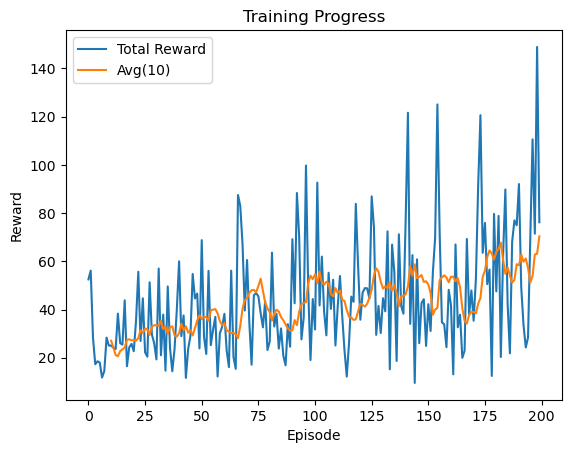

In [11]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- Policy Network ---
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(4, 2)

    def forward(self, x):
        return self.fc(x)

# --- Setup ---
env = gym.make("CartPole-v1")
net = PolicyNetwork()
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
episode_rewards =[]
# --- Training ---
for episode in range(200):

    obs, _ = env.reset()

    log_probs = []
    rewards = []
    

    done = False

    # 🔁 Episode loop
    while not done:

        obs_tensor = torch.tensor(obs, dtype=torch.float32)

        logits = net(obs_tensor)
        probs = F.softmax(logits, dim=0)

        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        log_probs.append(log_prob)

        obs, reward, terminated, truncated, _ = env.step(action.item())
        pole_angle = obs[2]
        reward = reward - abs(pole_angle) # reward shaping
        rewards.append(reward)

        done = terminated or truncated

   #  episode_rewards.append(sum(rewards))

   # if len(episode_rewards) >= 10:
   #      avg_reward = sum(episode_rewards[-10:]) / 10
   #      print(f"Episode {episode} - Avg(10): {avg_reward}")

    # 🔥 Episode bitti → learning başlıyor

    # --- Returns hesapla ---
    returns = []
    G = 0

    for r in reversed(rewards):
        G = r + G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)
    #returns = returns - returns.mean()
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # --- Loss hesapla ---
    loss_terms = []

    for log_prob, G in zip(log_probs, returns):
        loss_terms.append(-log_prob * G)

    loss = torch.stack(loss_terms).sum()

    # --- Update ---
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_reward = sum(rewards)
    episode_rewards.append(total_reward)
    
    if len(episode_rewards) >= 10:
        avg_reward = sum(episode_rewards[-10:]) / 10
        print(f"Episode {episode} | Total: {total_reward:.2f} | Avg(10): {avg_reward:.2f}")
    else:
        print(f"Episode {episode} | Total: {total_reward:.2f}")

plt.figure()
plt.plot(episode_rewards, label="Total Reward")

# moving average hesapla
window = 10
moving_avg = []

for i in range(len(episode_rewards)):
    if i >= window:
        avg = sum(episode_rewards[i-window:i]) / window
        moving_avg.append(avg)
    else:
        moving_avg.append(None)

plt.plot(moving_avg, label="Avg(10)")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Progress")
plt.legend()
plt.show()

env.close()

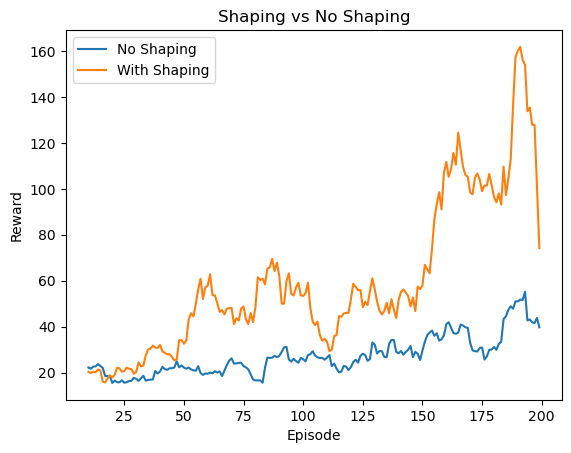

In [12]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Policy Network ---
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(4, 2)

    def forward(self, x):
        return self.fc(x)

# --- TRAIN FUNCTION ---
def train(shaping=False):

    env = gym.make("CartPole-v1")
    net = PolicyNetwork()
    optimizer = optim.Adam(net.parameters(), lr=0.01)

    episode_rewards = []

    for episode in range(200):

        obs, _ = env.reset()

        log_probs = []
        rewards = []

        done = False

        while not done:

            obs_tensor = torch.tensor(obs, dtype=torch.float32)

            logits = net(obs_tensor)
            probs = F.softmax(logits, dim=0)

            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            log_probs.append(log_prob)

            obs, reward, terminated, truncated, _ = env.step(action.item())

            # 🔥 reward shaping kontrolü
            if shaping:
                pole_angle = obs[2]
                reward = reward - abs(pole_angle)

            rewards.append(reward)

            done = terminated or truncated

        # --- episode bitti ---
        total_reward = sum(rewards)
        episode_rewards.append(total_reward)

        # --- returns ---
        returns = []
        G = 0

        for r in reversed(rewards):
            G = r + G
            returns.insert(0, G)

        returns = torch.tensor(returns, dtype=torch.float32)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # --- loss ---
        loss_terms = []
        for log_prob, G in zip(log_probs, returns):
            loss_terms.append(-log_prob * G)

        loss = torch.stack(loss_terms).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    env.close()
    return episode_rewards

# --- MOVING AVERAGE ---
def moving_avg(data, window=10):
    result = []
    for i in range(len(data)):
        if i >= window:
            avg = sum(data[i-window:i]) / window
            result.append(avg)
        else:
            result.append(None)
    return result

# 🔥 RUN 1: NO SHAPING
rewards_no = train(shaping=False)

# 🔥 RUN 2: SHAPING
rewards_shape = train(shaping=True)

# --- PLOT ---
plt.figure()

plt.plot(moving_avg(rewards_no), label="No Shaping")
plt.plot(moving_avg(rewards_shape), label="With Shaping")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Shaping vs No Shaping")
plt.legend()

plt.show()